In [1]:
from muon import MuData
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import mudata as md

# mu.set_options(display_style = "html", display_html_expand = 0b000)

In [2]:
rna = sc.read_h5ad('../../../oscb/uploads/scicar_cell_lines_mod1.h5ad')
rna

AnnData object with n_obs × n_vars = 4739 × 60550
    obs: 'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors'
    var: 'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_svd', 'mode2'
    layers: 'counts', 'normalized'

In [3]:
rna.layers['counts'].todense()

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [4]:
rna.X = rna.layers['counts'].copy()
rna.layers['raw_counts'] = rna.layers['counts'].copy()
del rna.layers['counts']
rna

AnnData object with n_obs × n_vars = 4739 × 60550
    obs: 'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors'
    var: 'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_svd', 'mode2'
    layers: 'normalized', 'raw_counts'

In [5]:
rna.X.todense()

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [6]:
atac = sc.read_h5ad('../../../oscb/uploads/scicar_cell_lines_mod2.h5ad')
atac

AnnData object with n_obs × n_vars = 4739 × 146713
    obs: 'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type'
    var: 'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score'
    uns: 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id'
    obsm: 'X_svd'
    layers: 'counts', 'normalized'

In [7]:
atac.X = atac.layers['counts'].copy()
atac.layers['raw_counts'] = atac.layers['counts'].copy()
del atac.layers['counts']
atac

AnnData object with n_obs × n_vars = 4739 × 146713
    obs: 'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type'
    var: 'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score'
    uns: 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id'
    obsm: 'X_svd'
    layers: 'normalized', 'raw_counts'

In [8]:
mdata = MuData({"rna": rna, "atac": atac})
mdata

/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 4739 × 207263
  var:	'feature_name', 'hvg', 'hvg_score'
  2 modalities
    rna:	4739 x 60550
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors'
      var:	'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score'
      uns:	'_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
      obsm:	'X_svd', 'mode2'
      layers:	'normalized', 'raw_counts'
    atac:	4739 x 146713
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type'
      var:	'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score'
      uns:	'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id'
      obsm:	'X_svd'
      layers:	'normalized', 'raw_counts'

In [9]:
mdata.write("../../../oscb/uploads/scicar_cell_lines0.h5mu")

/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [9]:
mdata.__str__()

"MuData object with n_obs × n_vars = 4739 × 207263\n  var:\t'feature_name', 'hvg', 'hvg_score'\n  2 modalities\n    rna:\t4739 x 60550\n      obs:\t'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors'\n      var:\t'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score'\n      uns:\t'_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'\n      obsm:\t'X_svd', 'mode2'\n      layers:\t'normalized', 'raw_counts'\n    atac:\t4739 x 146713\n      obs:\t'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type'\n      var:\t'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score'\n      uns:\t'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normaliz

In [10]:
mdata.var_names_make_unique()

# RNA

In [11]:
rna = mdata.mod['rna']
rna

AnnData object with n_obs × n_vars = 4739 × 60550
    obs: 'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors'
    var: 'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all'
    obsm: 'X_svd', 'mode2'
    layers: 'normalized', 'raw_counts'

In [12]:
rna.var['mt'] = rna.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(rna, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

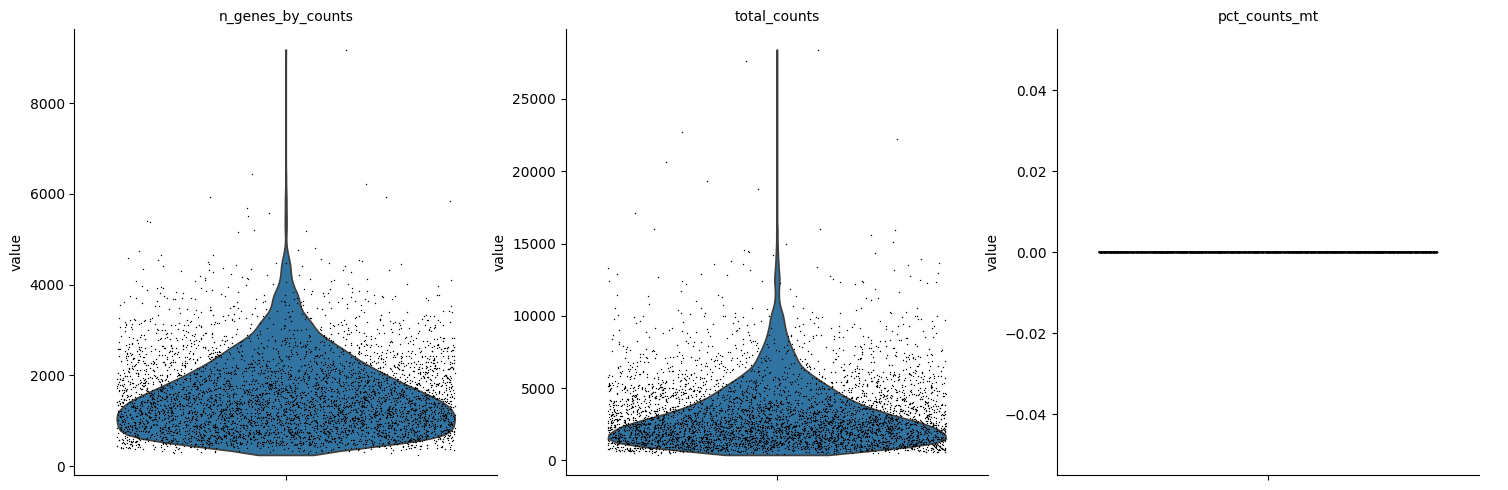

In [13]:
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

In [14]:
print(f"Before: {rna.n_obs} cells")
mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= 200) & (x < 8000))
print(f"(After n_genes: {rna.n_obs} cells)")
mu.pp.filter_obs(rna, 'total_counts', lambda x: x < 40000)
print(f"(After total_counts: {rna.n_obs} cells)")
mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x < 20)
print(f"After: {rna.n_obs} cells")

Before: 4739 cells
(After n_genes: 4738 cells)
(After total_counts: 4738 cells)
After: 4738 cells


In [15]:
# # Filter genes which expression is not detected
# mu.pp.filter_var(rna, 'n_cells_by_counts', lambda x: x >= 3)
# # This is analogous to
# #   sc.pp.filter_genes(rna, min_cells=3)
# # but does in-place filtering and avoids copying the object

In [16]:
# # Filter cells
# mu.pp.filter_obs(rna, 'n_genes_by_counts', lambda x: (x >= 200) & (x < 5000))
# # This is analogous to
# #   sc.pp.filter_cells(rna, min_genes=200)
# #   rna = rna[rna.obs.n_genes_by_counts < 5000, :]
# # but does in-place filtering avoiding copying the object

# mu.pp.filter_obs(rna, 'total_counts', lambda x: x < 40000)
# mu.pp.filter_obs(rna, 'pct_counts_mt', lambda x: x < 20)

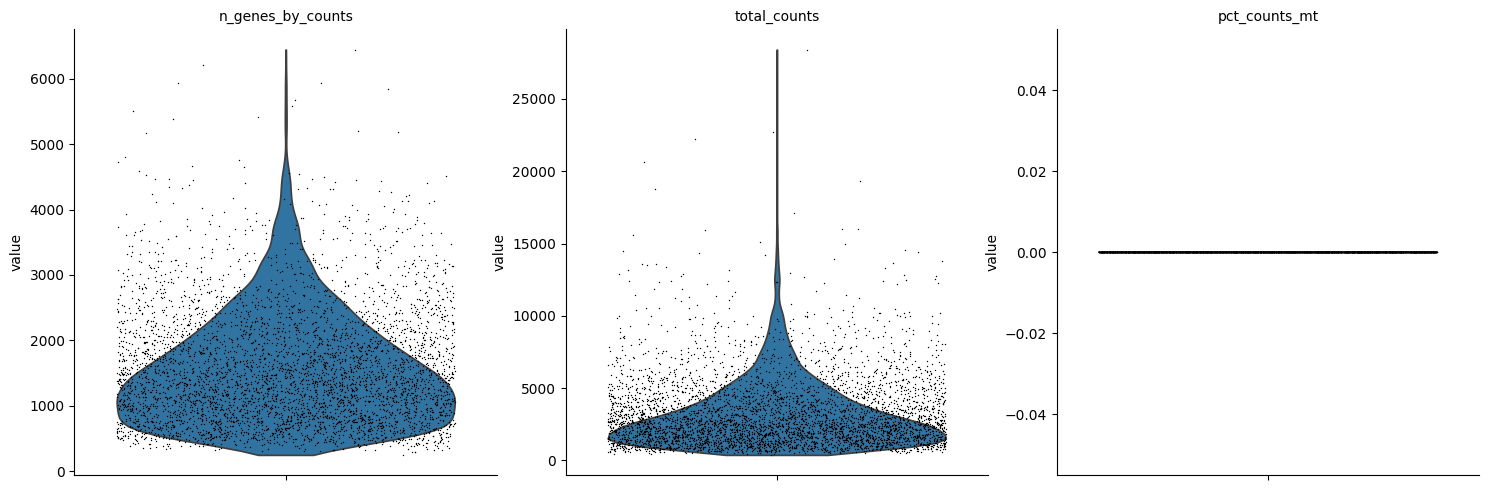

In [17]:
sc.pl.violin(rna, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

## Normalisation

In [18]:
# sc.pp.normalize_total(rna, target_sum=1e4)
# sc.pp.log1p(rna)

rna.layers["raw_counts"] = rna.X.copy()
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
# rna.raw = rna
rna.layers["LogCP10K"] = rna.X.copy()

## Feature selection

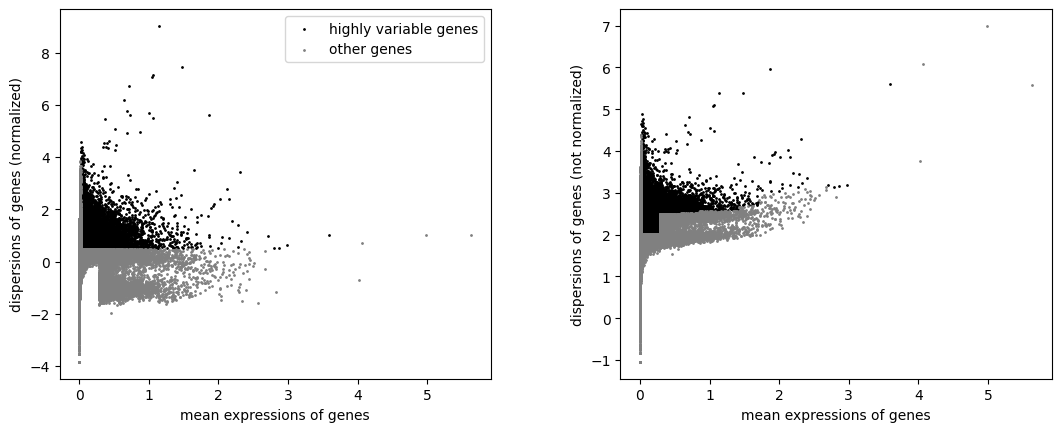

In [19]:
sc.pp.highly_variable_genes(rna, min_mean=0.02, max_mean=4, min_disp=0.5)
sc.pl.highly_variable_genes(rna)

In [20]:
np.sum(rna.var.highly_variable)

12251

## Scaling

In [21]:
# rna.raw = rna

In [22]:
sc.pp.scale(rna, max_value=10)

/opt/conda/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## Analysis

In [23]:
sc.tl.pca(rna, svd_solver='arpack')
sc.pp.neighbors(rna, n_neighbors=10, n_pcs=20)


In [24]:
sc.tl.leiden(rna, resolution=.5)

/tmp/ipykernel_8865/151724384.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna, resolution=.5)


In [25]:
sc.tl.umap(rna, spread=1., min_dist=.5, random_state=11)

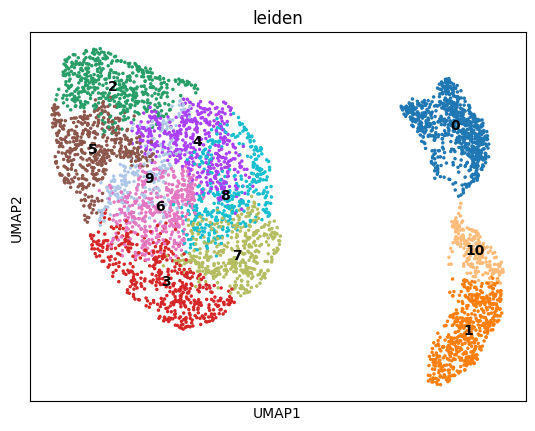

In [26]:
sc.pl.umap(rna, color="leiden", legend_loc="on data")

In [27]:
mdata.write("../../../oscb/uploads/scicar_cell_lines.h5mu")

/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


# ATAC

In [28]:
from muon import atac as ac

In [29]:
atac = mdata.mod['atac']

In [30]:
sc.pp.calculate_qc_metrics(atac, percent_top=None, log1p=False, inplace=True)

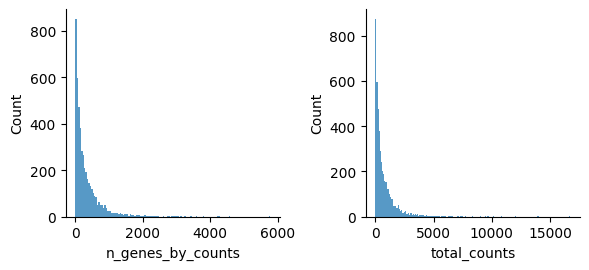

In [31]:
mu.pl.histogram(atac, ['n_genes_by_counts', 'total_counts'], linewidth=0)

In [32]:
mu.pp.filter_var(atac, 'n_cells_by_counts', lambda x: x >= 10)

In [33]:
print(f"Before: {atac.n_obs} cells")
mu.pp.filter_obs(atac, 'total_counts', lambda x: (x >= 1000) & (x <= 80000))
print(f"(After total_counts: {atac.n_obs} cells)")
mu.pp.filter_obs(atac, 'n_genes_by_counts', lambda x: (x >= 100) & (x <= 30000))
print(f"After: {atac.n_obs} cells")

Before: 4739 cells
(After total_counts: 1151 cells)
After: 1151 cells


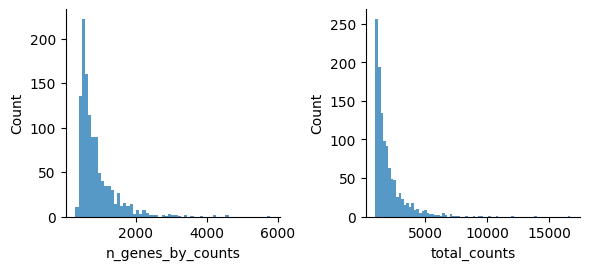

In [34]:
mu.pl.histogram(atac, ['n_genes_by_counts', 'total_counts'], linewidth=0)

## Nucleosome signal

In [35]:
# ac.pl.fragment_histogram(atac, region='chr1:1-2000000')

In [36]:
# mu.atac.tl.locate_fragments(atac)

In [37]:
# ac.tl.nucleosome_signal(atac, n=1e6)

## TSS enrichment

In [38]:
# ac.tl.get_gene_annotation_from_rna(mdata['rna']).head(3)  # accepts MuData with 'rna' modality or mdata['rna'] AnnData directly

In [39]:
# tss = ac.tl.tss_enrichment(mdata, n_tss=1000)  # by default, features=ac.tl.get_gene_annotation_from_rna(mdata)
# tss

In [40]:
# ac.pl.tss_enrichment(tss)

## Normalisation

In [41]:
atac.layers["counts"] = atac.X.copy()
sc.pp.normalize_total(atac, target_sum=1e4)
sc.pp.log1p(atac)
atac.layers["lognorm"] = atac.X.copy()

## Define informative features

In [42]:
sc.pp.highly_variable_genes(atac, min_mean=0.05, max_mean=1.5, min_disp=.5)

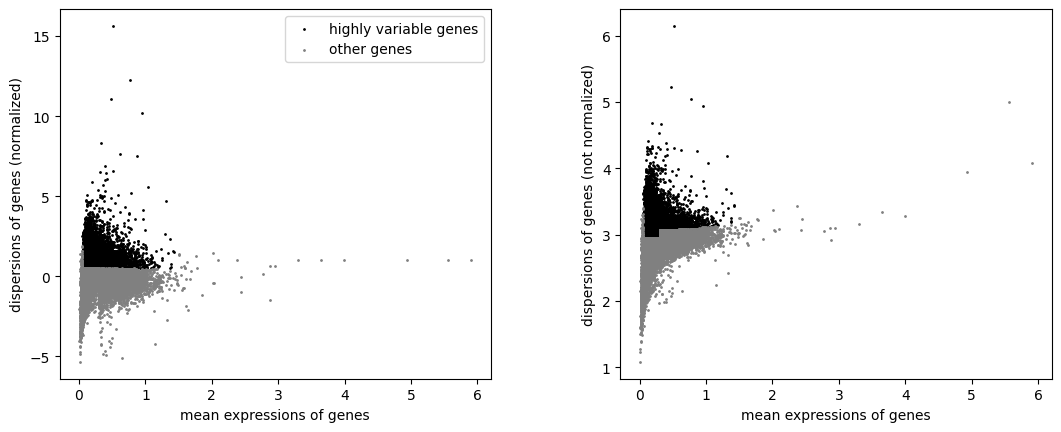

In [43]:
sc.pl.highly_variable_genes(atac)

In [44]:
np.sum(atac.var.highly_variable)

8646

## Scaling and PCA

In [45]:
sc.pp.scale(atac, max_value=10)
sc.tl.pca(atac, svd_solver='arpack')
# Finding cell neighbours and clustering cells
sc.pp.neighbors(atac, n_neighbors=10, n_pcs=20)
sc.tl.leiden(atac, resolution=.5)

/opt/conda/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [46]:
sc.tl.umap(atac, spread=1., min_dist=.5, random_state=11)

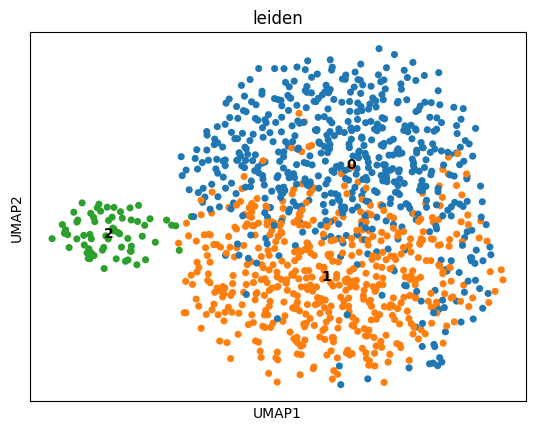

In [47]:
sc.pl.umap(atac, color="leiden", legend_loc="on data")

In [48]:
rna

AnnData object with n_obs × n_vars = 4738 × 60550
    obs: 'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all', 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
    obsm: 'X_svd', 'mode2', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'normalized', 'raw_counts', 'LogCP10K'
    obsp: 'distances', 'connectivities'

# Multi-omics integration

In [49]:
mdata.update()
mu.pp.intersect_obs(mdata)

/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/opt/conda/lib/python3.11/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalit

In [10]:
!pip install cupy-cuda12x

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


## MOFA


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='rna' group='group1' with N=1151 samples and D=12251 features...
Loaded view='atac' group='group1' with N=1151 samples and D=8646 features...



Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights:

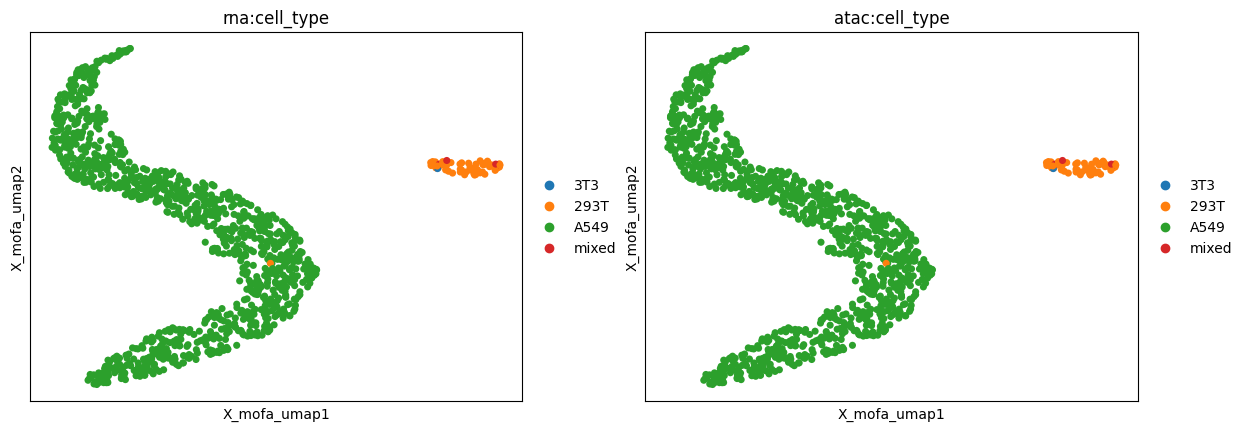

In [50]:
mu.tl.mofa(mdata, n_factors=20, gpu_mode=True)
sc.pp.neighbors(mdata, use_rep="X_mofa")
sc.tl.umap(mdata, random_state=1)
mdata.obsm["X_mofa_umap"] = mdata.obsm["X_umap"]
mu.pl.embedding(mdata, basis="X_mofa_umap", color=["rna:cell_type", "atac:cell_type"])

## WNN

In [51]:
# Since subsetting was performed after calculating nearest neighbours,
# we have to calculate them again for each modality.
sc.pp.neighbors(mdata['rna'])
sc.pp.neighbors(mdata['atac'])

# Calculate weighted nearest neighbors
mu.pp.neighbors(mdata, key_added='wnn')

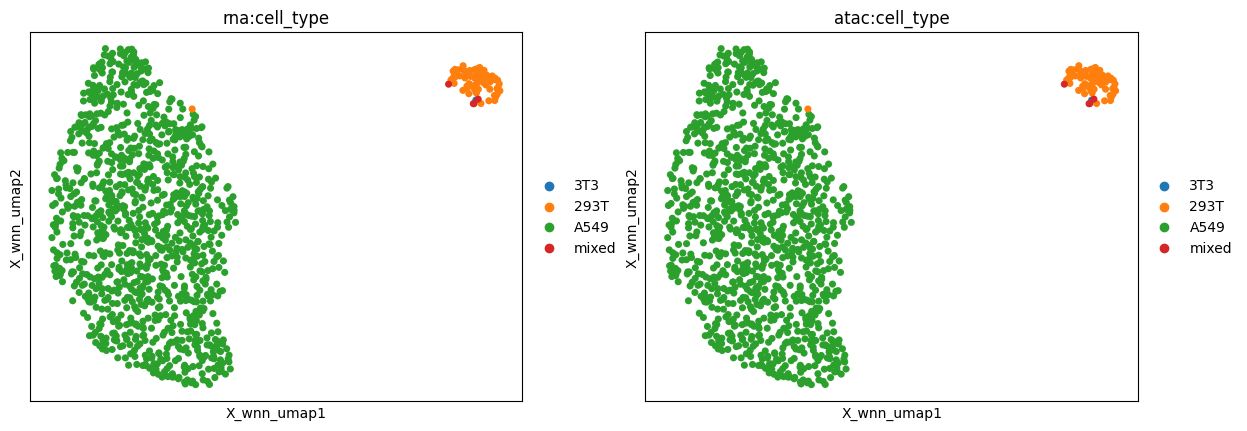

In [52]:
mu.tl.umap(mdata, neighbors_key='wnn', random_state=10)
mdata.obsm["X_wnn_umap"] = mdata.obsm["X_umap"]
mu.pl.embedding(mdata, basis="X_wnn_umap", color=["rna:cell_type", "atac:cell_type"])


In [53]:
mdata.write("../../../oscb/uploads/scicar_cell_lines.h5mu")

In [54]:
mdata

MuData object with n_obs × n_vars = 1151 × 92524
  var:	'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
  uns:	'mofa', 'neighbors', 'umap', 'wnn'
  obsm:	'X_mofa', 'X_umap', 'X_mofa_umap', 'X_wnn_umap'
  varm:	'LFs'
  obsp:	'distances', 'connectivities', 'wnn_distances', 'wnn_connectivities'
  2 modalities
    rna:	1151 x 60550
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'size_factors', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden'
      var:	'gene_type', 'gene_short_name', 'n_counts', 'feature_name', 'hvg', 'hvg_score', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'_from_cache', 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'var_names_all', 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
      obsm:	'X_svd', 'mode2', 'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'normalized', 'raw_counts', 'LogCP10K'
      obsp:	'distances', 'connectivities'
    atac:	1151 x 31974
      obs:	'cell_name', 'experiment', 'treatment_time', 'source', 'group', 'cell_type', 'n_genes_by_counts', 'total_counts', 'leiden'
      var:	'id', 'chr', 'start', 'end', 'feature_name', 'hvg', 'hvg_score', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_reference', 'dataset_summary', 'dataset_url', 'normalization_id', 'log1p', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
      obsm:	'X_svd', 'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	'normalized', 'raw_counts', 'counts', 'lognorm'
      obsp:	'distances', 'connectivities'

In [56]:
mdata['rna'].obsm['X_umap'].shape

(1151, 2)

In [58]:
mdata.obsm['X_wnn_umap'].shape

(1151, 2)

In [59]:
mdata['atac'].obsm['X_umap'].shape

(1151, 2)

In [61]:
mdata.obsm['X_mofa'].shape

(1151, 20)

In [62]:
mdata.var

,rna:gene_type,rna:gene_short_name,rna:n_counts,rna:mt,atac:id,atac:chr,atac:start,atac:end,feature_name,hvg,...,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
ENSG00000227232.4,pseudogene,WASH7P,17.0,False,NaN,NaN,NaN,NaN,ENSG00000227232.4,False,...,9,0.003587,99.810087,17.0,False,0.011956,2.126039,0.658982,0.003567,0.084353
ENSG00000238009.2,lincRNA,RP11-34P13.7,4.0,False,NaN,NaN,NaN,NaN,ENSG00000238009.2,False,...,4,0.000844,99.915594,4.0,False,0.004275,2.212229,0.781292,0.001297,0.049286
ENSG00000237683.5,protein_coding,AL627309.1,8.0,False,NaN,NaN,NaN,NaN,ENSG00000237683.5,False,...,6,0.001688,99.873391,8.0,False,0.006315,2.087799,0.604716,0.002080,0.061065
ENSG00000268903.1,pseudogene,RP11-34P13.15,8.0,False,NaN,NaN,NaN,NaN,ENSG00000268903.1,True,...,3,0.001688,99.936696,8.0,False,0.010151,3.455807,2.546021,0.001516,0.064593
ENSG00000241860.2,processed_transcript,RP11-34P13.13,2.0,False,NaN,NaN,NaN,NaN,ENSG00000241860.2,False,...,2,0.000422,99.957797,2.0,False,0.001133,1.288326,-0.529794,0.000507,0.026437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hs37d5-35312124-35312606,NaN,NaN,NaN,<NA>,189572.0,hs37d5,35312124.0,35312606.0,hs37d5-35312124-35312606,False,...,12,0.004642,99.746782,22.0,False,0.085489,2.773358,-0.070466,0.017257,0.212227
hs37d5-35372168-35372717,NaN,NaN,NaN,<NA>,189586.0,hs37d5,35372168.0,35372717.0,hs37d5-35372168-35372717,False,...,12,0.004009,99.746782,19.0,False,0.053751,2.654701,-0.440353,0.012004,0.170561
hs37d5-35391131-35391550,NaN,NaN,NaN,<NA>,189589.0,hs37d5,35391131.0,35391550.0,hs37d5-35391131-35391550,False,...,11,0.004853,99.767884,23.0,True,0.128472,3.409274,1.911858,0.019447,0.239236
hs37d5-35412204-35412447,NaN,NaN,NaN,<NA>,189595.0,hs37d5,35412204.0,35412447.0,hs37d5-35412204-35412447,False,...,15,0.003798,99.683478,18.0,False,0.032087,2.595361,-0.625333,0.008169,0.131760


In [64]:
# if is_ensembl(mdata.var_names[0]):
#     print("Convert Ensembl IDs to gene symbols.")
#     if 'species' is not None:
#         try:
#             ensembl_ids = mdata.var.index.tolist()
#             symbol_ids = ensembl_to_symbol(ensembl_ids, species=species)
#             mdata.var['gene_symbols'] = symbol_ids
#             mdata.var['ensembl_ids'] = ensembl_ids
#             mdata.var = mdata.var.set_index('gene_symbols')
#         except Exception as e:
#             print(f"An error occurred when converting Ensembl IDs to gene symbols, skipped: {e}")
#     else:
#         print("{species} is not supported by ensembl_to_symbol(), skipped.")

In [65]:
mdata.obs

,rna:cell_name,rna:experiment,rna:treatment_time,rna:source,rna:group,rna:cell_type,rna:size_factors,rna:n_genes_by_counts,rna:total_counts,rna:total_counts_mt,...,atac:experiment,atac:treatment_time,atac:source,atac:group,atac:cell_type,atac:n_genes_by_counts,atac:total_counts,atac:leiden,rna:mod_weight,atac:mod_weight
sci-RNA-A-001.CGTATTGAGA,A549,co_assay,3.0,Human,A549_3h,A549,1259.0,765,1259.0,0.0,...,co_assay,3.0,Human,A549_3h,A549,599,1473.0,0,0.935841,0.064159
sci-RNA-A-001.GACCAATGCG,A549,co_assay,0.0,Human,A549_0h,A549,926.0,606,926.0,0.0,...,co_assay,0.0,Human,A549_0h,A549,444,1069.0,0,0.999993,0.000007
sci-RNA-A-002.ACGCGTATCG,293T,co_assay,NaN,Human,293T_3T3,293T,6637.0,2865,6637.0,0.0,...,co_assay,NaN,Human,293T_3T3,293T,528,1180.0,2,0.999994,0.000006
sci-RNA-A-003.TCTCTCATCC,A549,co_assay,0.0,Human,A549_0h,A549,14328.0,4538,14328.0,0.0,...,co_assay,0.0,Human,A549_0h,A549,1006,2372.0,0,0.998152,0.001848
sci-RNA-A-003.TTCTCTACTA,A549,co_assay,1.0,Human,A549_1h,A549,1571.0,900,1571.0,0.0,...,co_assay,1.0,Human,A549_1h,A549,1323,3081.0,1,0.842837,0.157163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sci-RNA-E-094.TCTAGTCAAG,A549,co_assay,1.0,Human,A549_1h,A549,2999.0,1503,2999.0,0.0,...,co_assay,1.0,Human,A549_1h,A549,735,1684.0,0,0.771010,0.228990
sci-RNA-E-095.CTGAAGAGAC,A549,co_assay,1.0,Human,A549_1h,A549,1322.0,780,1322.0,0.0,...,co_assay,1.0,Human,A549_1h,A549,697,1423.0,0,0.999873,0.000127
sci-RNA-E-096.AATCGAACTC,A549,co_assay,1.0,Human,A549_1h,A549,2702.0,1480,2702.0,0.0,...,co_assay,1.0,Human,A549_1h,A549,1819,4036.0,1,0.841273,0.158727
sci-RNA-E-096.CGAATCTCCT,A549,co_assay,3.0,Human,A549_3h,A549,3099.0,1532,3099.0,0.0,...,co_assay,3.0,Human,A549_3h,A549,562,1211.0,0,0.985198,0.014802


In [78]:
mdata.obs

,rna:cell_name,rna:experiment,rna:treatment_time,rna:source,rna:group,rna:cell_type,rna:size_factors,rna:n_genes_by_counts,rna:total_counts,rna:total_counts_mt,...,atac:experiment,atac:treatment_time,atac:source,atac:group,atac:cell_type,atac:n_genes_by_counts,atac:total_counts,atac:leiden,rna:mod_weight,atac:mod_weight
sci-RNA-A-001.CGTATTGAGA,A549,co_assay,3.0,Human,A549_3h,A549,1259.0,765,1259.0,0.0,...,co_assay,3.0,Human,A549_3h,A549,599,1473.0,0,0.935841,0.064159
sci-RNA-A-001.GACCAATGCG,A549,co_assay,0.0,Human,A549_0h,A549,926.0,606,926.0,0.0,...,co_assay,0.0,Human,A549_0h,A549,444,1069.0,0,0.999993,0.000007
sci-RNA-A-002.ACGCGTATCG,293T,co_assay,NaN,Human,293T_3T3,293T,6637.0,2865,6637.0,0.0,...,co_assay,NaN,Human,293T_3T3,293T,528,1180.0,2,0.999994,0.000006
sci-RNA-A-003.TCTCTCATCC,A549,co_assay,0.0,Human,A549_0h,A549,14328.0,4538,14328.0,0.0,...,co_assay,0.0,Human,A549_0h,A549,1006,2372.0,0,0.998152,0.001848
sci-RNA-A-003.TTCTCTACTA,A549,co_assay,1.0,Human,A549_1h,A549,1571.0,900,1571.0,0.0,...,co_assay,1.0,Human,A549_1h,A549,1323,3081.0,1,0.842837,0.157163
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sci-RNA-E-094.TCTAGTCAAG,A549,co_assay,1.0,Human,A549_1h,A549,2999.0,1503,2999.0,0.0,...,co_assay,1.0,Human,A549_1h,A549,735,1684.0,0,0.771010,0.228990
sci-RNA-E-095.CTGAAGAGAC,A549,co_assay,1.0,Human,A549_1h,A549,1322.0,780,1322.0,0.0,...,co_assay,1.0,Human,A549_1h,A549,697,1423.0,0,0.999873,0.000127
sci-RNA-E-096.AATCGAACTC,A549,co_assay,1.0,Human,A549_1h,A549,2702.0,1480,2702.0,0.0,...,co_assay,1.0,Human,A549_1h,A549,1819,4036.0,1,0.841273,0.158727
sci-RNA-E-096.CGAATCTCCT,A549,co_assay,3.0,Human,A549_3h,A549,3099.0,1532,3099.0,0.0,...,co_assay,3.0,Human,A549_3h,A549,562,1211.0,0,0.985198,0.014802


In [76]:
rna.X.shape

(1151, 60550)

In [77]:
atac.X.shape

(1151, 31974)

In [79]:
rna.obs

,cell_name,experiment,treatment_time,source,group,cell_type,size_factors,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden
sci-RNA-A-001.CGTATTGAGA,A549,co_assay,3.0,Human,A549_3h,A549,1259.0,765,1259.0,0.0,0.0,5
sci-RNA-A-001.GACCAATGCG,A549,co_assay,0.0,Human,A549_0h,A549,926.0,606,926.0,0.0,0.0,2
sci-RNA-A-002.ACGCGTATCG,293T,co_assay,NaN,Human,293T_3T3,293T,6637.0,2865,6637.0,0.0,0.0,1
sci-RNA-A-003.TCTCTCATCC,A549,co_assay,0.0,Human,A549_0h,A549,14328.0,4538,14328.0,0.0,0.0,7
sci-RNA-A-003.TTCTCTACTA,A549,co_assay,1.0,Human,A549_1h,A549,1571.0,900,1571.0,0.0,0.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
sci-RNA-E-094.TCTAGTCAAG,A549,co_assay,1.0,Human,A549_1h,A549,2999.0,1503,2999.0,0.0,0.0,4
sci-RNA-E-095.CTGAAGAGAC,A549,co_assay,1.0,Human,A549_1h,A549,1322.0,780,1322.0,0.0,0.0,2
sci-RNA-E-096.AATCGAACTC,A549,co_assay,1.0,Human,A549_1h,A549,2702.0,1480,2702.0,0.0,0.0,3
sci-RNA-E-096.CGAATCTCCT,A549,co_assay,3.0,Human,A549_3h,A549,3099.0,1532,3099.0,0.0,0.0,4
